# Exercise: Coffee Batch

**Module 2: Data Visualization** | Lean Six Sigma Data Analytics

---

## The Scenario

We measured the caffeine percentage of coffee. Previously, we made a boxplot and saw a big difference between caffeine percentage produced on three different machines. We found that **machine 3 did not comply** with the maximum of 0.1% caffeine for decaf coffee.

However, next to the machine we also measured the **batch number**.

## Question to Answer

1. Is **batch** also an influence factor for caffeine percentage?
2. If so, which batch is best to produce decaf coffee?

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Minitab-style house style -------------------------------------------
import sys
from pathlib import Path as _Path

# minitab_style.py lives in the parent folder of each module directory
sys.path.append(str(_Path.cwd().parent))
import minitab_style as ms

ms.apply_style()

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)
print('Data loaded successfully!')


Data loaded successfully!


---

## Step 1: Identify Variables and Methods

| Variable | Role | Type | Why? |
|----------|------|------|------|
| Caffeine % | Y (CTQ) | Numerical | Continuous measurement |
| Batch Number | X (Influence Factor) | **Categorical** | Don't be fooled by the number! |

**Key Insight:** Batch number looks numerical but it's categorical. The numbers are labels (Batch 1, 2, 3...), not measurements.

### Decision Tree

| Y Variable | X Variable | Graph Type |
|------------|------------|------------|
| Numerical | Categorical | **Boxplot with groups** |

In [2]:
# Load Caffeine-3 data
caffeine3 = pd.read_excel(xlsx, sheet_name='Caffeine-3', skiprows=6)
caffeine3.columns = ['Caffeine_Pct', 'Extractor', 'Batch']
caffeine3 = caffeine3.dropna()
caffeine3['Caffeine_Pct'] = pd.to_numeric(caffeine3['Caffeine_Pct'], errors='coerce')
caffeine3 = caffeine3.dropna()

print(f'Dataset: {caffeine3.shape[0]} measurements')
print(f'Variables:')
print(f'  - Caffeine_Pct: Numerical (continuous)')
print(f'  - Batch: Categorical ({caffeine3["Batch"].nunique()} unique values: {sorted(caffeine3["Batch"].unique())})')
caffeine3.head()

Dataset: 60 measurements
Variables:
  - Caffeine_Pct: Numerical (continuous)
  - Batch: Categorical (10 unique values: [718, 719, 720, 721, 722, 723, 724, 725, 726, 727])


,Caffeine_Pct,Extractor,Batch
1,0.053180,1,718
2,0.056994,2,718
3,0.112809,3,718
4,0.052463,1,718
5,0.083227,2,718


---

## Step 2: Boxplot with Groups

**Method:** Numerical Y + Categorical X = Boxplot with groups

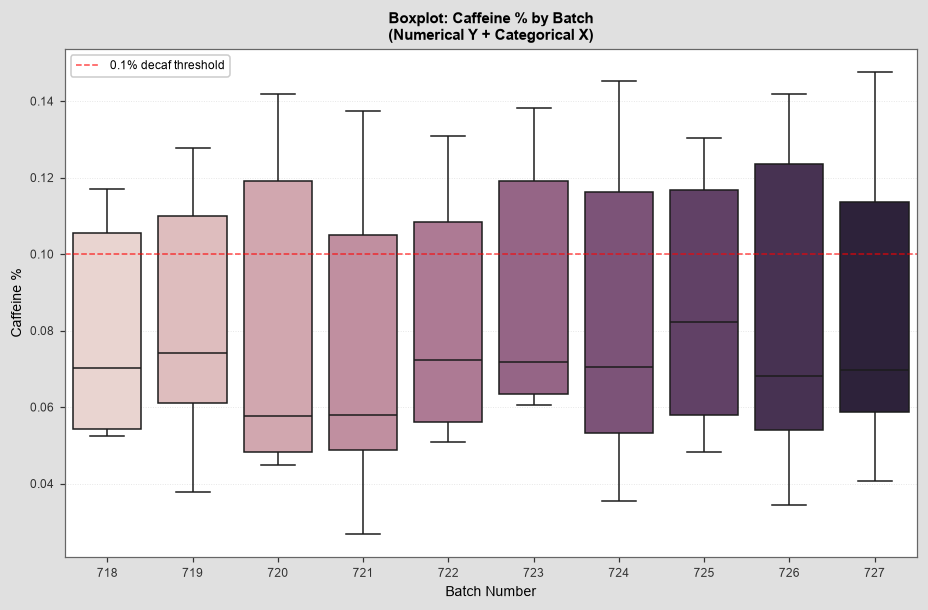

Summary by Batch:


,N,Mean,Median,StdDev,Max
Batch,,,,,
718,6,0.0793,0.0701,0.0299,0.1170
719,6,0.0820,0.0740,0.0356,0.1277
720,6,0.0812,0.0578,0.0464,0.1418
721,6,0.0744,0.0580,0.0436,0.1375
722,6,0.0829,0.0723,0.0340,0.1309
723,6,0.0896,0.0717,0.0361,0.1381
724,6,0.0835,0.0704,0.0449,0.1453
725,6,0.0868,0.0822,0.0352,0.1302
726,6,0.0839,0.0680,0.0460,0.1419


In [3]:
# Boxplot by Batch - equivalent to Minitab: Graph > Boxplot > With Groups
plt.figure(figsize=(10, 6))
sns.boxplot(x='Batch', y='Caffeine_Pct', data=caffeine3,
            hue='Batch', legend=False)
plt.axhline(0.1, color='red', linestyle='--', alpha=0.7, label='0.1% decaf threshold')
plt.xlabel('Batch Number')
plt.ylabel('Caffeine %')
plt.title('Boxplot: Caffeine % by Batch\n(Numerical Y + Categorical X)')
plt.legend()
plt.show()

# Summary statistics by Batch
print('Summary by Batch:')
summary = caffeine3.groupby('Batch')['Caffeine_Pct'].agg(['count', 'mean', 'median', 'std', 'max'])
summary.columns = ['N', 'Mean', 'Median', 'StdDev', 'Max']
display(summary.round(4))

---

## Step 3: Analyze Results

In [4]:
# Check compliance with 0.1% threshold
threshold = 0.1

print('Compliance Analysis by Batch:')
print('=' * 50)
for batch in sorted(caffeine3['Batch'].unique()):
    batch_data = caffeine3[caffeine3['Batch'] == batch]['Caffeine_Pct']
    exceeds = (batch_data > threshold).sum()
    total = len(batch_data)
    max_val = batch_data.max()
    compliant = 'YES' if max_val <= threshold else 'NO'
    print(f'  Batch {batch}: Max = {max_val:.4f}% | Compliant: {compliant}')

print('\n' + '=' * 50)
print('ANSWERS:')
print('=' * 50)
print('\n1. Is batch an influence factor?')
print('   NO - There are no big differences between the medians')
print('   and boxes for each batch. Batch number is NOT an')
print('   important influence factor for caffeine percentage.')
print('\n2. Which batch is best for decaf?')
print('   NONE - Not a single batch complies with the 0.1%')
print('   maximum for decaf coffee.')

Compliance Analysis by Batch:
  Batch 718: Max = 0.1170% | Compliant: NO
  Batch 719: Max = 0.1277% | Compliant: NO
  Batch 720: Max = 0.1418% | Compliant: NO
  Batch 721: Max = 0.1375% | Compliant: NO
  Batch 722: Max = 0.1309% | Compliant: NO
  Batch 723: Max = 0.1381% | Compliant: NO
  Batch 724: Max = 0.1453% | Compliant: NO
  Batch 725: Max = 0.1302% | Compliant: NO
  Batch 726: Max = 0.1419% | Compliant: NO
  Batch 727: Max = 0.1476% | Compliant: NO

ANSWERS:

1. Is batch an influence factor?
   NO - There are no big differences between the medians
   and boxes for each batch. Batch number is NOT an
   important influence factor for caffeine percentage.

2. Which batch is best for decaf?
   NONE - Not a single batch complies with the 0.1%
   maximum for decaf coffee.


---

## Comparison: Batch vs Extractor

Let's compare batch (not an influence factor) with extractor (known influence factor).

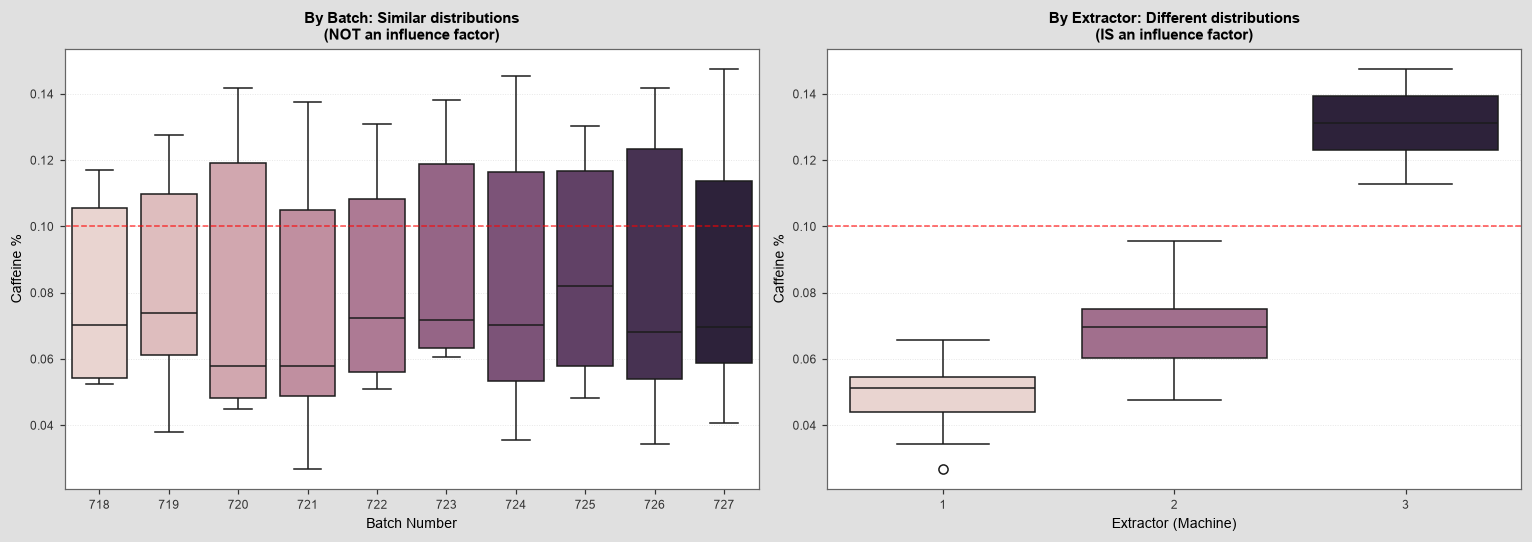

Visual Comparison:
  - Batch: Medians and boxes are similar across batches
  - Extractor: Clear differences between machines (especially Machine 3)


In [5]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By Batch (NOT an influence factor)
sns.boxplot(x='Batch', y='Caffeine_Pct', data=caffeine3,
            hue='Batch', legend=False, ax=axes[0])
axes[0].axhline(0.1, color='red', linestyle='--', alpha=0.7)
axes[0].set_xlabel('Batch Number')
axes[0].set_ylabel('Caffeine %')
axes[0].set_title('By Batch: Similar distributions\n(NOT an influence factor)')

# By Extractor (IS an influence factor)
sns.boxplot(x='Extractor', y='Caffeine_Pct', data=caffeine3,
            hue='Extractor', legend=False, ax=axes[1])
axes[1].axhline(0.1, color='red', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Extractor (Machine)')
axes[1].set_ylabel('Caffeine %')
axes[1].set_title('By Extractor: Different distributions\n(IS an influence factor)')

plt.tight_layout()
plt.show()

print('Visual Comparison:')
print('  - Batch: Medians and boxes are similar across batches')
print('  - Extractor: Clear differences between machines (especially Machine 3)')

---

## Summary

| Question | Answer |
|----------|--------|
| Is batch an influence factor? | No - distributions are similar across batches |
| Which batch is best for decaf? | None - all batches exceed 0.1% threshold |

---

## Key Takeaways

- **Numbers can be categorical:** Batch 1, 2, 3 are labels, not measurements
- **Numerical Y + Categorical X:** Use boxplot with groups
- **Identifying influence factors:** Look for differences in medians and box positions
- **Similar distributions across groups:** Variable is NOT an influence factor
- **Different distributions across groups:** Variable IS an influence factor